In [ ]:
import gymnasium as gym
import tensorflow as tf
import numpy as np
import cv2
from collections import deque
from datetime import datetime
from pathlib import Path
import keras
from tensorflow.summary import create_file_writer
import os
import matplotlib.pyplot as plt

def pid(error, prev_error):
    Kp, Ki, Kd = 0.02, 0.03, 0.2
    return Kp * error + Ki * (error + prev_error) + Kd * (error - prev_error)

def preprocess_frame(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (36, 25, 25), (70, 255, 255))
    green = np.zeros_like(frame)
    green[mask > 0] = frame[mask > 0]
    gray = cv2.cvtColor(green, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    canny = cv2.Canny(blur, 50, 150)
    cropped = canny[200:202, 200:400]
    return cropped

def find_error(crop, prev_error):
    nz = cv2.findNonZero(crop)
    mid = 100
    if nz is None:
        return prev_error
    if nz[:, 0, 0].max() == nz[:, 0, 0].min():
        return -15 if nz[:, 0, 0].max() >= mid else 15
    return ((nz[:, 0, 0].max() + nz[:, 0, 0].min()) / 2) - mid

def build_model():
    image_input = tf.keras.Input(shape=(2, 200, 1), name="canny_crop")

    # Use kernels that span full height, and pool only on width
    x1 = tf.keras.layers.Conv2D(16, (2, 5), padding="valid", activation="relu")(image_input)
    x1 = tf.keras.layers.MaxPooling2D(pool_size=(1, 2))(x1)  # only reduce width
    x1 = tf.keras.layers.Conv2D(32, (1, 3), padding="same", activation="relu")(x1)
    x1 = tf.keras.layers.MaxPooling2D(pool_size=(1, 2))(x1)  # reduce width again
    x1 = tf.keras.layers.Flatten()(x1)

    # Simpler error input
    error_input = tf.keras.Input(shape=(1,), name="error")
    x2 = tf.keras.layers.Dense(8, activation="relu")(error_input)

    # Fuse and output Q-values for 3 gas levels
    concat = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Dense(32, activation="relu")(concat)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.models.Model(inputs=[image_input, error_input], outputs=output)
    model.compile(optimizer="adam", loss="mse")
    return model


def preprocess_inputs(crop, error):
    crop = crop.astype(np.float32) / 255.0
    crop = crop.reshape(1, 2, 200, 1)
    return [crop, np.array([[error / 100]], dtype=np.float32)]

def train_step(ep):
    batch_size = min(64, len(replay_buffer) // 10)
    batch = [replay_buffer[np.random.randint(len(replay_buffer))] for _ in range(batch_size)]

    # Unpack: each sample is (crop, error, gas, reward, next_crop, next_error, done)
    crops, errors, actions, rewards, next_crops, next_errors, dones = zip(*batch)

    # Format inputs
    X_img = np.array(crops).reshape(batch_size, 5, 200, 1)
    X_err = np.array(errors).reshape(batch_size, 1)
    next_img = np.array(next_crops).reshape(batch_size, 5, 200, 1)
    next_err = np.array(next_errors).reshape(batch_size, 1)
    rewards = np.array(rewards).reshape(batch_size, 1)
    dones = np.array(dones).astype(np.float32).reshape(batch_size, 1)

    # Double Q: use main to pick next action, target to evaluate it
    next_pred = model.predict([next_img, next_err], verbose=0)
    next_q = target_model.predict([next_img, next_err], verbose=0)

    # Compute target: r + γ * Q'(s', a') * (1 - done)
    gamma = 0.99
    targets = rewards + gamma * next_q * (1 - dones)

    # Train main network toward target
    loss = model.train_on_batch([X_img, X_err], targets)

    losses.append(loss)
    with writer.as_default():
        tf.summary.scalar("Loss/train", loss, step=ep)


In [ ]:
model = build_model()
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
writer = create_file_writer(log_dir)

replay_buffer = deque(maxlen=20000)
env = gym.make("CarRacing-v3", render_mode="rgb_array", lap_complete_percent=0.95, domain_randomize=False, continuous=True)
np.random.seed(42)
tf.random.set_seed(42)
env.reset(seed=42)

episodes = 20
rewards = []
best_score = -1000
losses = []

In [ ]:
for ep in range(episodes):
    obs, _ = env.reset()
    total_reward = 0
    prev_error = 0
    smoothed_reward = 0

    for step in range(1000):
        frame = env.render()
        crop = preprocess_frame(frame)
        error = find_error(crop, prev_error)

        steering = pid(error, prev_error)
        gas = float(model.predict(preprocess_inputs(crop, error), verbose=0)[0][0])
 
        obs, reward, terminated, truncated, _ = env.step(action)
        smoothed_reward = 0.9 * smoothed_reward + 0.1 * float(reward)
        total_reward += smoothed_reward
        replay_buffer.append((crop, error, action_index))
        prev_error = error

        if len(replay_buffer) > 1000 and step % 4 == 0:
            train_step(ep)
            tau = 0.005
            for var, target_var in zip(model.trainable_variables, target_model.trainable_variables):
                target_var.assign(tau * var + (1 - tau) * target_var)
            with writer.as_default():
                for layer in model.layers:
                    weights = layer.get_weights()
                    if weights:
                        tf.summary.histogram(f"{layer.name}/weights", weights[0], step=ep)

        if terminated or truncated:
            break


    print(f"Episode {ep+1} - Reward: {total_reward:.2f}")
    rewards.append(total_reward)
    with writer.as_default():
        tf.summary.scalar("Reward/Episode", total_reward, step=ep)

    if total_reward > best_score:
        best_score = total_reward
        print(f" - New best score: {best_score:.2f}")
        if best_score > 100:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M")
            Path("models").mkdir(parents=True, exist_ok=True)
            file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
            keras.saving.save_model(model, file_path)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
Path("models").mkdir(parents=True, exist_ok=True)
file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
keras.saving.save_model(model, file_path)

env.close()
writer.close()

Episode 1 - Reward: -23.69
 - New best score: -23.69


In [ ]:
for ep in range(episodes):
    obs, _ = env.reset()
    total_reward = 0
    prev_error = 0
    smoothed_reward = 0

    for step in range(1000):
        frame = env.render()
        crop = preprocess_frame(frame)
        error = find_error(crop, prev_error)

        steering = pid(error, prev_error)
        q_values = model.predict(preprocess_inputs(crop, error), verbose=0)[0]
        action_index = np.argmax(q_values)

        # just gas
        action = np.array([steering, gas, 0], dtype=np.float32)

        # gas and break
        # pick = action_lst[action_index]
        # action = np.array([*pick, 0], dtype=np.float32)

        obs, reward, terminated, truncated, _ = env.step(action)
        smoothed_reward = 0.9 * smoothed_reward + 0.1 * float(reward)
        total_reward += smoothed_reward
        replay_buffer.append((crop, error, action_index))
        prev_error = error

        if len(replay_buffer) > 1000 and step % 4 == 0:
            train_step(ep)
            tau = 0.005
            for var, target_var in zip(model.trainable_variables, target_model.trainable_variables):
                target_var.assign(tau * var + (1 - tau) * target_var)
            with writer.as_default():
                for layer in model.layers:
                    weights = layer.get_weights()
                    if weights:
                        tf.summary.histogram(f"{layer.name}/weights", weights[0], step=ep)

        if terminated or truncated:
            break


    print(f"Episode {ep+1} - Reward: {total_reward:.2f}")
    rewards.append(total_reward)
    with writer.as_default():
        tf.summary.scalar("Reward/Episode", total_reward, step=ep)

    if total_reward > best_score:
        best_score = total_reward
        print(f" - New best score: {best_score:.2f}")
        if best_score > 100:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M")
            Path("models").mkdir(parents=True, exist_ok=True)
            file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
            keras.saving.save_model(model, file_path)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
Path("models").mkdir(parents=True, exist_ok=True)
file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
keras.saving.save_model(model, file_path)

env.close()
writer.close()

Episode 1 - Reward: -23.69
 - New best score: -23.69


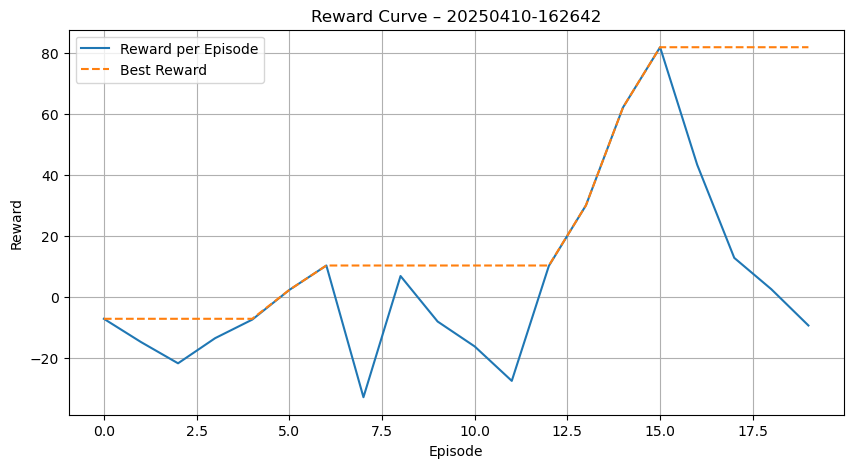

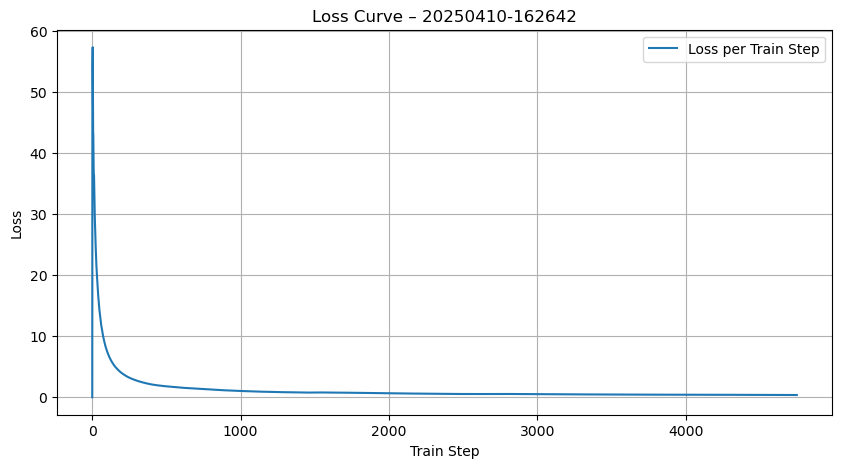

Saved plots to: images/20250410-162642_reward_plot_20250410_1704.png


In [23]:
# ========== Plot and Save Curves ==========
Path("images").mkdir(exist_ok=True)
model_name = Path(log_dir).name
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Reward Plot
plt.figure(figsize=(10, 5))
plt.plot(rewards, label="Reward per Episode")
plt.plot([max(rewards[:i+1]) for i in range(len(rewards))], linestyle='--', label="Best Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title(f"Reward Curve – {model_name}")
plt.grid(True)
plt.legend()
reward_path = f"images/{model_name}_reward_plot_{timestamp}.png"
plt.savefig(reward_path)
plt.show()

# Loss Plot
if losses:
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label="Loss per Train Step")
    plt.xlabel("Train Step")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve – {model_name}")
    plt.grid(True)
    plt.legend()
    loss_path = f"images/{model_name}_loss_plot_{timestamp}.png"
    plt.savefig(loss_path)
    plt.show()

print(f"Saved plots to: {reward_path}")